In [40]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline

C_ells_data = np.load("C_ells_shells_T_AGN_new.npz")
n_shells = len(C_ells_data['shell_boundaries_z']) - 1
C_ells_new = C_ells_data['C_ells']
ell_new = C_ells_data['ell']
sigma8_fid = C_ells_data['sigma_8_fid']
T_AGN_inter_new = C_ells_data['T_AGN']
zb = C_ells_data['shell_boundaries_z']



In [41]:
def get_c_ells(T_AGN =7.8, sigma8 = .8, lmax = 5000, C_ells=C_ells_new, T_AGN_inter = T_AGN_inter_new, ell = ell_new):
    ell_eval = np.arange(lmax)
    c_ells_return = np.zeros((n_shells,n_shells,len(ell_eval)))
    print(C_ells.shape)
    for i_shell in range(n_shells):
        for j_shell in range(i_shell,n_shells):
            C_ells_inter = RectBivariateSpline(T_AGN_inter, ell, sigma8**2/sigma8_fid**2*C_ells[:,i_shell, j_shell,:])
            c_ells_return[i_shell,j_shell,:] = C_ells_inter(T_AGN,ell_eval)
            c_ells_return[j_shell,i_shell,:] = c_ells_return[i_shell,j_shell,:]
    return ell_eval,c_ells_return
                
    

In [42]:
ells, test_cell = get_c_ells(T_AGN=6.8, sigma8=.8)


(15, 20, 20, 82)


(1e-10, 1)

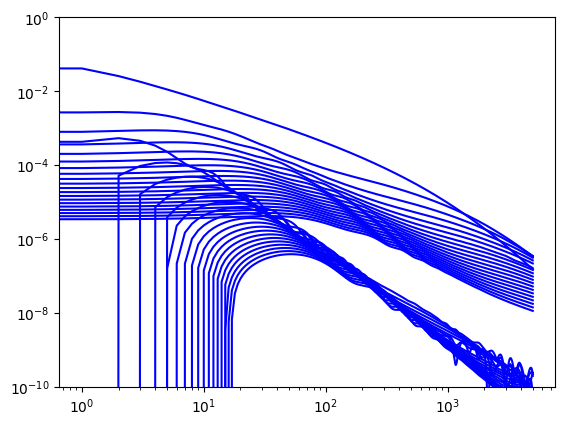

In [43]:
import matplotlib.pyplot as plt

for i_shell in range(n_shells):
    for j_shell in range(i_shell,n_shells):
        if np.abs(i_shell - j_shell) < 2:
            plt.loglog(ells, test_cell[i_shell,j_shell,:], color = "blue")

plt.ylim(1e-10,1)